# 🧰 Interactive Statistics Demonstration

This notebook demonstrates the statistical concepts from the Statistics for Dissertation Research section using Python. **You do not need to understand the code** — just run each cell (`Shift + Enter`) and read the output.

Each section matches a chapter in the statistics section of this eBook:
1. Descriptive Statistics
2. Inferential Statistics (t-tests, ANOVA, chi-square, correlation)
3. Effect Sizes
4. Assumption Checking
5. Regression
6. Reliability Analysis

---

## Setup

Run this cell first to load the required libraries:


In [1]:
# Run this cell first — it loads all required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set consistent style for all plots
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Seed for reproducibility
np.random.seed(42)

print("✅ All libraries loaded successfully!")
print("   numpy, matplotlib, scipy")
print()
print("You're ready to go. Run each cell below with Shift + Enter.")


✅ All libraries loaded successfully!
   numpy, matplotlib, scipy

You're ready to go. Run each cell below with Shift + Enter.


---

## 1. Descriptive Statistics

Descriptive statistics summarize your data. This section demonstrates measures of central tendency, variability, and visualization.

### Simulated Data

Imagine we surveyed 150 library users about their satisfaction (1–7 scale) and recorded the number of library visits per month.


In [2]:
# ─── SIMULATED DATASET ───
# 150 library users: satisfaction score (1-7) and visits per month

n = 150
satisfaction = np.clip(np.random.normal(4.8, 1.2, n).round(0), 1, 7)
visits = np.clip(np.random.exponential(5, n).round(0), 0, 30).astype(int)
group = np.random.choice(["Academic", "Public", "Special"], n, p=[0.45, 0.40, 0.15])

print("=" * 55)
print("  DESCRIPTIVE STATISTICS: SATISFACTION SCORES")
print("=" * 55)
print(f"  N            = {len(satisfaction)}")
print(f"  Mean (M)     = {satisfaction.mean():.2f}")
print(f"  Median       = {np.median(satisfaction):.1f}")
print(f"  Mode         = {stats.mode(satisfaction, keepdims=True).mode[0]:.0f}")
print(f"  Std Dev (SD) = {satisfaction.std(ddof=1):.2f}")
print(f"  Variance     = {satisfaction.var(ddof=1):.2f}")
print(f"  Range        = {satisfaction.min():.0f} to {satisfaction.max():.0f}")
print(f"  Skewness     = {stats.skew(satisfaction):.3f}")
print(f"  Kurtosis     = {stats.kurtosis(satisfaction):.3f}")
print("=" * 55)
print()
print("APA format:  M = {:.2f}, SD = {:.2f}".format(
    satisfaction.mean(), satisfaction.std(ddof=1)))


  DESCRIPTIVE STATISTICS: SATISFACTION SCORES
  N            = 150
  Mean (M)     = 4.69
  Median       = 5.0
  Mode         = 5
  Std Dev (SD) = 1.18
  Variance     = 1.40
  Range        = 2 to 7
  Skewness     = -0.002
  Kurtosis     = -0.352

APA format:  M = 4.69, SD = 1.18


### Visualizing Distributions

Histograms and box plots reveal the *shape* of your data — something numbers alone can miss.


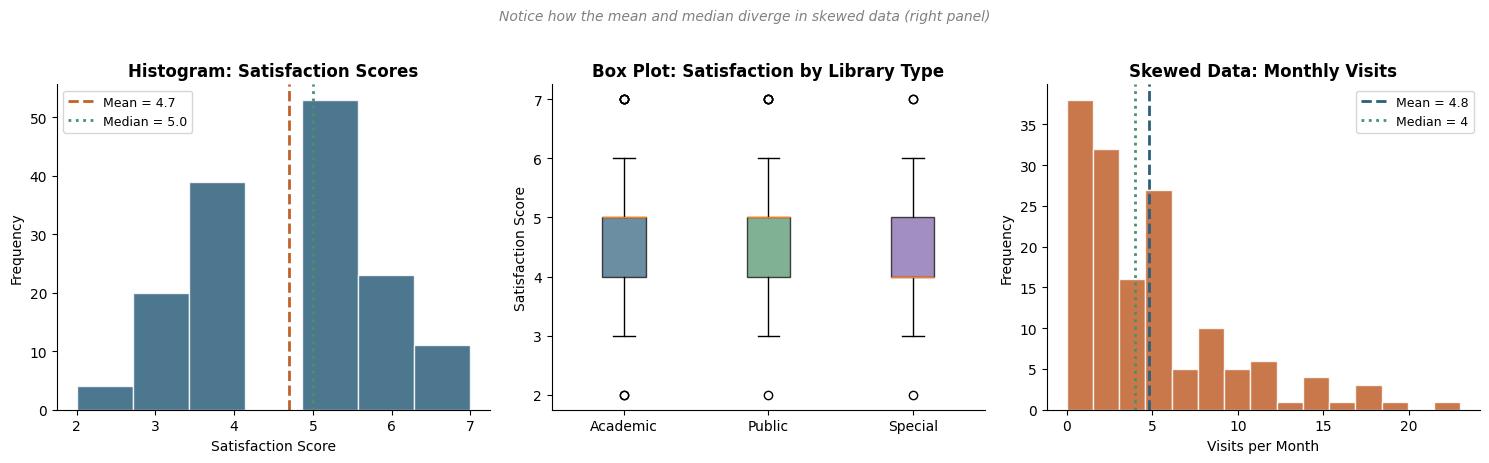

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Histogram
ax = axes[0]
ax.hist(satisfaction, bins=7, color="#2c5f7c", edgecolor="white", alpha=0.85)
ax.axvline(satisfaction.mean(), color="#c0612b", linewidth=2, linestyle="--", label=f"Mean = {satisfaction.mean():.1f}")
ax.axvline(np.median(satisfaction), color="#4a9068", linewidth=2, linestyle=":", label=f"Median = {np.median(satisfaction):.1f}")
ax.set_xlabel("Satisfaction Score")
ax.set_ylabel("Frequency")
ax.set_title("Histogram: Satisfaction Scores", fontweight="bold")
ax.legend(fontsize=9)

# Box plot by group
ax = axes[1]
data_by_group = [satisfaction[group == g] for g in ["Academic", "Public", "Special"]]
bp = ax.boxplot(data_by_group, labels=["Academic", "Public", "Special"],
                patch_artist=True, boxprops=dict(alpha=0.7))
colors = ["#2c5f7c", "#4a9068", "#7b5ea7"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
ax.set_ylabel("Satisfaction Score")
ax.set_title("Box Plot: Satisfaction by Library Type", fontweight="bold")

# Visits histogram (skewed data example)
ax = axes[2]
ax.hist(visits, bins=15, color="#c0612b", edgecolor="white", alpha=0.85)
ax.axvline(visits.mean(), color="#2c5f7c", linewidth=2, linestyle="--", label=f"Mean = {visits.mean():.1f}")
ax.axvline(np.median(visits), color="#4a9068", linewidth=2, linestyle=":", label=f"Median = {np.median(visits):.0f}")
ax.set_xlabel("Visits per Month")
ax.set_ylabel("Frequency")
ax.set_title("Skewed Data: Monthly Visits", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Notice how the mean and median diverge in skewed data (right panel)",
             fontsize=10, style="italic", color="gray", y=1.02)
plt.tight_layout()
plt.show()


### Frequency Table (Categorical Data)


In [4]:
print("=" * 40)
print("  FREQUENCY TABLE: LIBRARY TYPE")
print("=" * 40)
print(f"  {'Type':<12} {'Count':>6} {'Percent':>8}")
print("  " + "─" * 34)
for g in ["Academic", "Public", "Special"]:
    count = (group == g).sum()
    pct = count / len(group) * 100
    print(f"  {g:<12} {count:>6} {pct:>7.1f}%")
print("  " + "─" * 34)
print(f"  {'Total':<12} {len(group):>6} {'100.0%':>8}")
print("=" * 40)


  FREQUENCY TABLE: LIBRARY TYPE
  Type          Count  Percent
  ──────────────────────────────────
  Academic         64    42.7%
  Public           57    38.0%
  Special          29    19.3%
  ──────────────────────────────────
  Total           150   100.0%


---

## 2. Inferential Statistics

Inferential statistics help you draw conclusions about a *population* from your *sample*. Below are demonstrations of the most common tests.

### Independent Samples t-Test

*Question: Do academic and public library users differ in satisfaction?*


In [5]:
# Independent samples t-test
academic = satisfaction[group == "Academic"]
public = satisfaction[group == "Public"]

t_stat, p_value = stats.ttest_ind(academic, public)

# Effect size: Cohen's d
pooled_sd = np.sqrt(((len(academic)-1)*academic.std(ddof=1)**2 + 
                      (len(public)-1)*public.std(ddof=1)**2) / 
                     (len(academic) + len(public) - 2))
cohens_d = (academic.mean() - public.mean()) / pooled_sd

print("=" * 60)
print("  INDEPENDENT SAMPLES t-TEST")
print("  RQ: Do academic and public library users differ")
print("      in satisfaction?")
print("=" * 60)
print(f"  Academic:  M = {academic.mean():.2f}, SD = {academic.std(ddof=1):.2f}, n = {len(academic)}")
print(f"  Public:    M = {public.mean():.2f}, SD = {public.std(ddof=1):.2f}, n = {len(public)}")
print("  " + "─" * 52)
print(f"  t({len(academic)+len(public)-2}) = {t_stat:.3f}")
print(f"  p = {p_value:.4f}  {'← Significant (p < .05)' if p_value < .05 else '← Not significant'}")
print(f"  Cohen\'s d = {cohens_d:.3f}  ", end="")
if abs(cohens_d) < 0.2: print("(negligible effect)")
elif abs(cohens_d) < 0.5: print("(small effect)")
elif abs(cohens_d) < 0.8: print("(medium effect)")
else: print("(large effect)")
print("=" * 60)
print()
print("APA format:")
print(f"  t({len(academic)+len(public)-2}) = {abs(t_stat):.2f}, p = {p_value:.3f}, d = {abs(cohens_d):.2f}")


  INDEPENDENT SAMPLES t-TEST
  RQ: Do academic and public library users differ
      in satisfaction?
  Academic:  M = 4.67, SD = 1.25, n = 64
  Public:    M = 4.79, SD = 1.06, n = 57
  ────────────────────────────────────────────────────
  t(119) = -0.554
  p = 0.5805  ← Not significant
  Cohen's d = -0.101  (negligible effect)

APA format:
  t(119) = 0.55, p = 0.581, d = 0.10


### One-Way ANOVA

*Question: Does satisfaction differ across all three library types?*

Use ANOVA when you have 3+ groups. If significant, follow up with post-hoc tests to find *which* groups differ.


In [6]:
# One-Way ANOVA
special = satisfaction[group == "Special"]
f_stat, p_value = stats.f_oneway(academic, public, special)

# Effect size: eta-squared
grand_mean = satisfaction.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in [academic, public, special])
ss_total = sum((satisfaction - grand_mean)**2)
eta_sq = ss_between / ss_total

print("=" * 60)
print("  ONE-WAY ANOVA")
print("  RQ: Does satisfaction differ across library types?")
print("=" * 60)
print(f"  Academic:  M = {academic.mean():.2f}, SD = {academic.std(ddof=1):.2f}, n = {len(academic)}")
print(f"  Public:    M = {public.mean():.2f}, SD = {public.std(ddof=1):.2f}, n = {len(public)}")
print(f"  Special:   M = {special.mean():.2f}, SD = {special.std(ddof=1):.2f}, n = {len(special)}")
print("  " + "─" * 52)
print(f"  F(2, {len(satisfaction)-3}) = {f_stat:.3f}")
print(f"  p = {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print(f"  η² = {eta_sq:.3f}  ", end="")
if eta_sq < 0.01: print("(negligible)")
elif eta_sq < 0.06: print("(small effect)")
elif eta_sq < 0.14: print("(medium effect)")
else: print("(large effect)")
print("=" * 60)

if p_value < .05:
    print()
    print("  Since ANOVA is significant, we run post-hoc tests")
    print("  to determine WHICH groups differ:")
    print()
    pairs = [("Academic vs Public", academic, public),
             ("Academic vs Special", academic, special),
             ("Public vs Special", public, special)]
    for label, g1, g2 in pairs:
        _, p = stats.ttest_ind(g1, g2)
        p_bonf = min(p * 3, 1.0)  # Bonferroni correction
        sig = "* Significant" if p_bonf < .05 else "  Not significant"
        print(f"    {label:>22}: p = {p_bonf:.4f} (Bonferroni) {sig}")


  ONE-WAY ANOVA
  RQ: Does satisfaction differ across library types?
  Academic:  M = 4.67, SD = 1.25, n = 64
  Public:    M = 4.79, SD = 1.06, n = 57
  Special:   M = 4.55, SD = 1.27, n = 29
  ────────────────────────────────────────────────────
  F(2, 147) = 0.405
  p = 0.6681  ← Not significant
  η² = 0.005  (negligible)


### Pearson Correlation

*Question: Is there a relationship between number of visits and satisfaction?*


  PEARSON CORRELATION
  RQ: Is there a relationship between visits and
      satisfaction?
  r(148) = -0.075
  p = 0.3587  ← Not significant
  r² = 0.006 (0.6% of variance shared)
  ────────────────────────────────────────────────────
  Interpretation: weak negative relationship


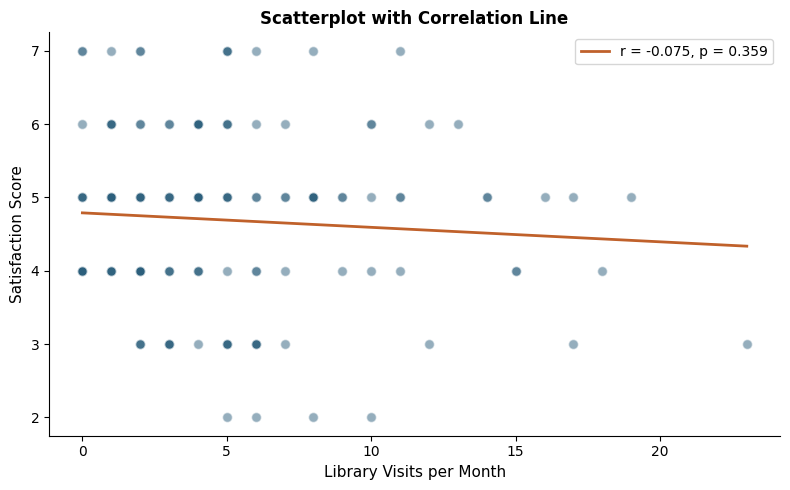

In [7]:
# Pearson correlation
r, p_value = stats.pearsonr(visits, satisfaction)

print("=" * 60)
print("  PEARSON CORRELATION")
print("  RQ: Is there a relationship between visits and")
print("      satisfaction?")
print("=" * 60)
print(f"  r({len(visits)-2}) = {r:.3f}")
print(f"  p = {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print(f"  r² = {r**2:.3f} ({r**2*100:.1f}% of variance shared)")
print("  " + "─" * 52)
strength = "weak" if abs(r) < .3 else "moderate" if abs(r) < .5 else "strong"
direction = "positive" if r > 0 else "negative"
print(f"  Interpretation: {strength} {direction} relationship")
print("=" * 60)

# Scatterplot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(visits, satisfaction, alpha=0.5, color="#2c5f7c", edgecolor="white", s=50)
z = np.polyfit(visits, satisfaction, 1)
x_line = np.linspace(visits.min(), visits.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="#c0612b", linewidth=2,
        label=f"r = {r:.3f}, p = {p_value:.3f}")
ax.set_xlabel("Library Visits per Month", fontsize=11)
ax.set_ylabel("Satisfaction Score", fontsize=11)
ax.set_title("Scatterplot with Correlation Line", fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Chi-Square Test of Independence

*Question: Is there an association between library type and format preference?*

Use chi-square when both variables are categorical.


In [9]:
# Chi-square test
# Simulate format preference data
format_pref = np.where(
    group == "Academic",
    np.random.choice(["Digital", "Print", "Both"], n, p=[0.55, 0.15, 0.30]),
    np.where(
        group == "Public",
        np.random.choice(["Digital", "Print", "Both"], n, p=[0.30, 0.35, 0.35]),
        np.random.choice(["Digital", "Print", "Both"], n, p=[0.40, 0.25, 0.35])
    )
)
# Keep only entries matching the group
format_pref = format_pref[:n]

# Build contingency table
lib_types = ["Academic", "Public", "Special"]
formats = ["Digital", "Print", "Both"]
observed = np.zeros((3, 3), dtype=int)
for i, lt in enumerate(lib_types):
    for j, fmt in enumerate(formats):
        observed[i, j] = ((group == lt) & (format_pref == fmt)).sum()

chi2, p_value, dof, expected = stats.chi2_contingency(observed)

# Cramér's V (effect size for chi-square)
n_total = observed.sum()
k = min(observed.shape)
cramers_v = np.sqrt(chi2 / (n_total * (k - 1)))

print("=" * 60)
print("  CHI-SQUARE TEST OF INDEPENDENCE")
print("  RQ: Is library type associated with format preference?")
print("=" * 60)
print()
print("  Observed Frequencies:")
print(f"  {'':>12} {'Digital':>8} {'Print':>8} {'Both':>8} {'Total':>8}")
print("  " + "─" * 48)
for i, lt in enumerate(lib_types):
    row_total = observed[i].sum()
    print(f"  {lt:>12} {observed[i,0]:>8} {observed[i,1]:>8} {observed[i,2]:>8} {row_total:>8}")
col_totals = observed.sum(axis=0)
print("  " + "─" * 48)
print(f"  {'Total':>12} {col_totals[0]:>8} {col_totals[1]:>8} {col_totals[2]:>8} {n_total:>8}")
print()
print(f"  χ²({dof}) = {chi2:.3f}")
print(f"  p = {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print(f"  Cramér\'s V = {cramers_v:.3f}  ", end="")
if cramers_v < .1: print("(negligible)")
elif cramers_v < .3: print("(small effect)")
elif cramers_v < .5: print("(medium effect)")
else: print("(large effect)")
print("=" * 60)


  CHI-SQUARE TEST OF INDEPENDENCE
  RQ: Is library type associated with format preference?

  Observed Frequencies:
                Digital    Print     Both    Total
  ────────────────────────────────────────────────
      Academic       36       11       17       64
        Public       21       16       20       57
       Special       13        7        9       29
  ────────────────────────────────────────────────
         Total       70       34       46      150

  χ²(4) = 4.785
  p = 0.3101  ← Not significant
  Cramér's V = 0.126  (small effect)


### Paired Samples t-Test

*Question: Did scores improve from pre-test to post-test?*

Use when the same people are measured twice (before/after, pre/post).


In [10]:
# Paired samples t-test (pre/post design)
pre_scores = np.random.normal(65, 12, 40).round(1)
post_scores = pre_scores + np.random.normal(8, 6, 40)  # Average improvement of ~8 points
post_scores = post_scores.round(1)

t_stat, p_value = stats.ttest_rel(post_scores, pre_scores)
diff = post_scores - pre_scores
cohens_d = diff.mean() / diff.std(ddof=1)

print("=" * 60)
print("  PAIRED SAMPLES t-TEST")
print("  RQ: Did information literacy scores improve after")
print("      the instruction program?")
print("=" * 60)
print(f"  Pre-test:   M = {pre_scores.mean():.2f}, SD = {pre_scores.std(ddof=1):.2f}")
print(f"  Post-test:  M = {post_scores.mean():.2f}, SD = {post_scores.std(ddof=1):.2f}")
print(f"  Difference: M = {diff.mean():.2f}, SD = {diff.std(ddof=1):.2f}")
print("  " + "─" * 52)
print(f"  t({len(pre_scores)-1}) = {t_stat:.3f}")
print(f"  p = {p_value:.6f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print(f"  Cohen\'s d = {cohens_d:.3f}  ", end="")
if abs(cohens_d) < 0.2: print("(negligible)")
elif abs(cohens_d) < 0.5: print("(small)")
elif abs(cohens_d) < 0.8: print("(medium)")
else: print("(large)")
print("=" * 60)


  PAIRED SAMPLES t-TEST
  RQ: Did information literacy scores improve after
      the instruction program?
  Pre-test:   M = 68.27, SD = 12.29
  Post-test:  M = 77.23, SD = 12.58
  Difference: M = 8.96, SD = 6.28
  ────────────────────────────────────────────────────
  t(39) = 9.020
  p = 0.000000  ← Significant
  Cohen's d = 1.426  (large)


---

## 3. Assumption Checking

Before running parametric tests, verify that your data meet the required assumptions. This dashboard checks normality, homogeneity of variance, and detects outliers.


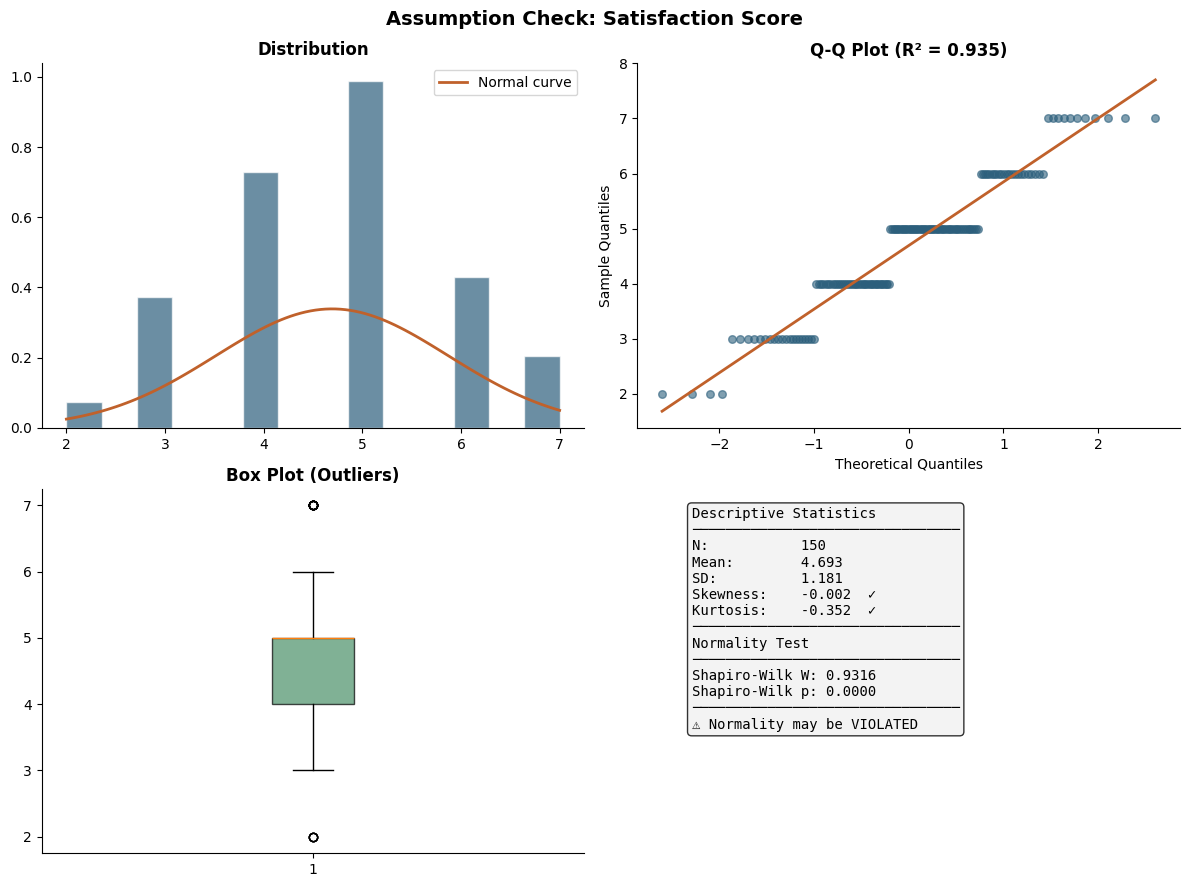

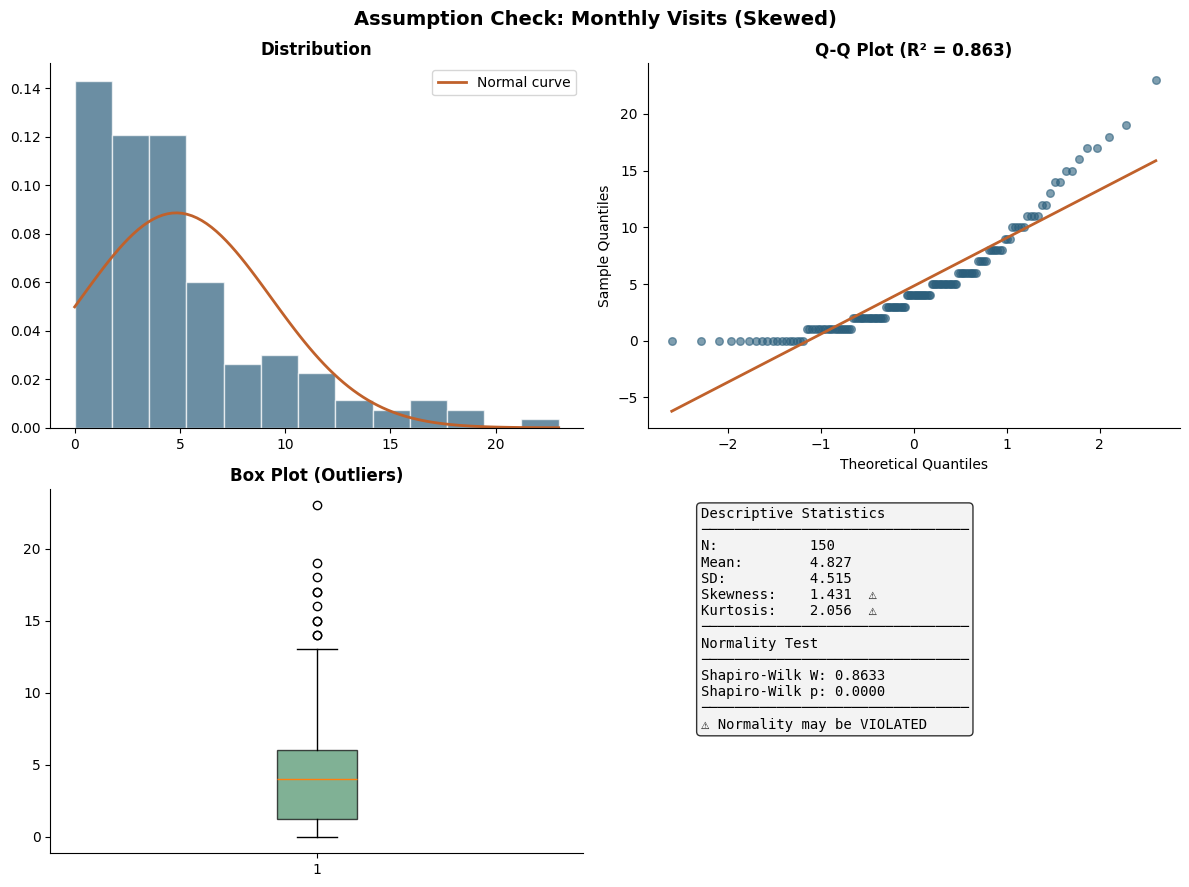

In [11]:
def assumption_dashboard(data, var_name="Variable"):
    """Four-panel assumption check."""
    data = np.array(data, dtype=float)
    data = data[~np.isnan(data)]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(f"Assumption Check: {var_name}", fontsize=14, fontweight="bold", y=0.98)

    # Histogram
    ax = axes[0, 0]
    ax.hist(data, bins="auto", density=True, alpha=0.7, color="#2c5f7c", edgecolor="white")
    x_range = np.linspace(data.min(), data.max(), 100)
    ax.plot(x_range, stats.norm.pdf(x_range, data.mean(), data.std()),
            color="#c0612b", linewidth=2, label="Normal curve")
    ax.set_title("Distribution", fontweight="bold")
    ax.legend()

    # Q-Q plot
    ax = axes[0, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, alpha=0.6, color="#2c5f7c", s=30)
    ax.plot(osm, slope * np.array(osm) + intercept, color="#c0612b", linewidth=2)
    ax.set_title(f"Q-Q Plot (R² = {r**2:.3f})", fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")

    # Box plot
    ax = axes[1, 0]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4a9068", alpha=0.7))
    ax.set_title("Box Plot (Outliers)", fontweight="bold")

    # Statistics panel
    ax = axes[1, 1]
    ax.axis("off")
    shapiro_stat, shapiro_p = stats.shapiro(data[:min(5000, len(data))])
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    txt = (f"Descriptive Statistics\n{'─'*32}\n"
           f"N:           {len(data)}\n"
           f"Mean:        {data.mean():.3f}\n"
           f"SD:          {data.std(ddof=1):.3f}\n"
           f"Skewness:    {skew:.3f}  {'✓' if abs(skew) < 1 else '⚠'}\n"
           f"Kurtosis:    {kurt:.3f}  {'✓' if abs(kurt) < 1 else '⚠'}\n"
           f"{'─'*32}\nNormality Test\n{'─'*32}\n"
           f"Shapiro-Wilk W: {shapiro_stat:.4f}\n"
           f"Shapiro-Wilk p: {shapiro_p:.4f}\n{'─'*32}\n")
    txt += "✓ Normality likely MET" if shapiro_p > .05 else "⚠ Normality may be VIOLATED"
    
    ax.text(0.1, 0.95, txt, transform=ax.transAxes, fontsize=10,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))

    plt.tight_layout()
    plt.show()

# Run on our satisfaction data
assumption_dashboard(satisfaction, "Satisfaction Score")

# Run on skewed visits data for comparison
assumption_dashboard(visits, "Monthly Visits (Skewed)")


### Homogeneity of Variance (Levene\'s Test)


In [12]:
# Levene's test for homogeneity of variance
levene_stat, levene_p = stats.levene(academic, public, special)

print("=" * 55)
print("  LEVENE'S TEST FOR HOMOGENEITY OF VARIANCE")
print("=" * 55)
print(f"  Academic SD = {academic.std(ddof=1):.3f}")
print(f"  Public   SD = {public.std(ddof=1):.3f}")
print(f"  Special  SD = {special.std(ddof=1):.3f}")
print("  " + "─" * 47)
print(f"  Levene\'s F = {levene_stat:.3f}")
print(f"  p = {levene_p:.4f}")
print("  " + "─" * 47)
if levene_p > .05:
    print("  ✓ Variances are approximately equal (assumption MET)")
    print("    → Safe to proceed with standard ANOVA")
else:
    print("  ⚠ Variances are significantly different (assumption VIOLATED)")
    print("    → Consider Welch\'s ANOVA or Brown-Forsythe test")
print("=" * 55)


  LEVENE'S TEST FOR HOMOGENEITY OF VARIANCE
  Academic SD = 1.248
  Public   SD = 1.065
  Special  SD = 1.270
  ───────────────────────────────────────────────
  Levene's F = 1.183
  p = 0.3091
  ───────────────────────────────────────────────
  ✓ Variances are approximately equal (assumption MET)
    → Safe to proceed with standard ANOVA


---

## 4. Simple Linear Regression

*Question: Can we predict satisfaction from number of visits?*

Regression goes beyond correlation — it provides an equation for prediction and tells you how much variance the predictor explains.


  SIMPLE LINEAR REGRESSION
  DV: Satisfaction Score
  IV: Monthly Visits
  Regression equation:
    Satisfaction = 4.789 + -0.020 × Visits

  Slope (b):    -0.0197
  Intercept:    4.7886
  r:            -0.0755
  R²:           0.0057 (0.6% variance explained)
  p:            0.3587  ← Not significant
  Std Error:    0.0214

  Interpretation: For each additional visit per month,
  satisfaction decreases by 0.020 points.


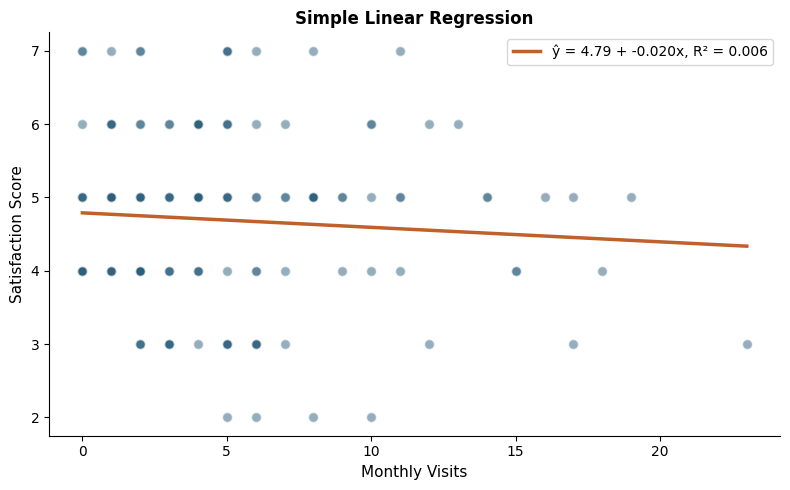

In [13]:
# Simple linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(visits, satisfaction)

print("=" * 60)
print("  SIMPLE LINEAR REGRESSION")
print("  DV: Satisfaction Score")
print("  IV: Monthly Visits")
print("=" * 60)
print(f"  Regression equation:")
print(f"    Satisfaction = {intercept:.3f} + {slope:.3f} × Visits")
print()
print(f"  Slope (b):    {slope:.4f}")
print(f"  Intercept:    {intercept:.4f}")
print(f"  r:            {r_value:.4f}")
print(f"  R²:           {r_value**2:.4f} ({r_value**2*100:.1f}% variance explained)")
print(f"  p:            {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print(f"  Std Error:    {std_err:.4f}")
print("=" * 60)
print()
print("  Interpretation: For each additional visit per month,")
print(f"  satisfaction {'increases' if slope > 0 else 'decreases'} by {abs(slope):.3f} points.")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(visits, satisfaction, alpha=0.5, color="#2c5f7c", edgecolor="white", s=50)
x_line = np.linspace(0, visits.max(), 100)
ax.plot(x_line, intercept + slope * x_line, color="#c0612b", linewidth=2.5,
        label=f"ŷ = {intercept:.2f} + {slope:.3f}x, R² = {r_value**2:.3f}")
ax.set_xlabel("Monthly Visits", fontsize=11)
ax.set_ylabel("Satisfaction Score", fontsize=11)
ax.set_title("Simple Linear Regression", fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---

## 5. Reliability Analysis (Cronbach\'s Alpha)

If you're using a survey with multiple items measuring the same construct, Cronbach\'s alpha tells you how internally consistent the scale is.


In [14]:
def cronbachs_alpha(items):
    """Calculate Cronbach's alpha."""
    items = np.array(items, dtype=float)
    n_items = items.shape[1]
    item_vars = items.var(axis=0, ddof=1)
    total_var = items.sum(axis=1).var(ddof=1)
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

def item_analysis(items, labels=None):
    """Show alpha-if-item-deleted."""
    items = np.array(items, dtype=float)
    n_items = items.shape[1]
    if labels is None:
        labels = [f"Item {i+1}" for i in range(n_items)]
    
    full_alpha = cronbachs_alpha(items)
    print(f"  Overall α = {full_alpha:.3f}")
    if full_alpha >= .90: interp = "Excellent"
    elif full_alpha >= .80: interp = "Good"
    elif full_alpha >= .70: interp = "Acceptable"
    elif full_alpha >= .60: interp = "Questionable"
    else: interp = "Poor — consider revising"
    print(f"  Interpretation: {interp}")
    print()
    print(f"  {'Item':<18} {'α if deleted':<14} {'Action'}")
    print("  " + "─" * 50)
    
    for i in range(n_items):
        reduced = np.delete(items, i, axis=1)
        reduced_alpha = cronbachs_alpha(reduced)
        flag = "← CONSIDER REMOVING" if reduced_alpha > full_alpha + 0.01 else ""
        print(f"  {labels[i]:<18} {reduced_alpha:.3f}{'':<10} {flag}")

# Simulated 6-item survey scale (30 respondents)
np.random.seed(42)
n_resp = 30
base = np.random.normal(4.0, 1.0, n_resp)
survey_items = np.column_stack([
    np.clip(base + np.random.normal(0, 0.4, n_resp), 1, 7).round(),
    np.clip(base + np.random.normal(0, 0.5, n_resp), 1, 7).round(),
    np.clip(base + np.random.normal(0, 0.4, n_resp), 1, 7).round(),
    np.clip(base + np.random.normal(0, 0.6, n_resp), 1, 7).round(),
    np.clip(base + np.random.normal(0, 0.5, n_resp), 1, 7).round(),
    np.clip(np.random.normal(4.0, 1.5, n_resp), 1, 7).round()  # Weak item
])

item_names = ["Q1_Access", "Q2_Quality", "Q3_Navigation",
              "Q4_Support", "Q5_Satisfaction", "Q6_Unrelated"]

print("=" * 60)
print("  RELIABILITY ANALYSIS (CRONBACH'S ALPHA)")
print("  6-item survey scale, 30 respondents")
print("=" * 60)
item_analysis(survey_items, item_names)
print("=" * 60)
print()
print("  Note: Q6_Unrelated was intentionally designed as a weak")
print("  item. Removing it would improve scale reliability.")
print("  Convention: α ≥ .70 is acceptable (Nunnally, 1994)")


  RELIABILITY ANALYSIS (CRONBACH'S ALPHA)
  6-item survey scale, 30 respondents
  Overall α = 0.865
  Interpretation: Good

  Item               α if deleted   Action
  ──────────────────────────────────────────────────
  Q1_Access          0.825           
  Q2_Quality         0.821           
  Q3_Navigation      0.822           
  Q4_Support         0.836           
  Q5_Satisfaction    0.814           
  Q6_Unrelated       0.922           ← CONSIDER REMOVING

  Note: Q6_Unrelated was intentionally designed as a weak
  item. Removing it would improve scale reliability.
  Convention: α ≥ .70 is acceptable (Nunnally, 1994)


---

## 6. Nonparametric Tests

When your data violate parametric assumptions (non-normal distribution, ordinal data), use nonparametric alternatives.


In [15]:
# Mann-Whitney U (nonparametric alternative to independent t-test)
u_stat, p_value = stats.mannwhitneyu(academic, public, alternative="two-sided")

print("=" * 60)
print("  MANN-WHITNEY U TEST")
print("  (Nonparametric alternative to independent t-test)")
print("  RQ: Do academic and public library users differ?")
print("=" * 60)
print(f"  Academic median = {np.median(academic):.1f}, n = {len(academic)}")
print(f"  Public median   = {np.median(public):.1f}, n = {len(public)}")
print(f"  U = {u_stat:.1f}")
print(f"  p = {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print("=" * 60)
print()

# Spearman correlation (nonparametric alternative to Pearson)
rho, p_value = stats.spearmanr(visits, satisfaction)

print("=" * 60)
print("  SPEARMAN RANK CORRELATION")
print("  (Nonparametric alternative to Pearson r)")
print("  RQ: Is there a rank-order relationship between")
print("      visits and satisfaction?")
print("=" * 60)
print(f"  rₛ = {rho:.3f}")
print(f"  p = {p_value:.4f}  {'← Significant' if p_value < .05 else '← Not significant'}")
print("=" * 60)


  MANN-WHITNEY U TEST
  (Nonparametric alternative to independent t-test)
  RQ: Do academic and public library users differ?
  Academic median = 5.0, n = 64
  Public median   = 5.0, n = 57
  U = 1745.0
  p = 0.6716  ← Not significant

  SPEARMAN RANK CORRELATION
  (Nonparametric alternative to Pearson r)
  RQ: Is there a rank-order relationship between
      visits and satisfaction?
  rₛ = -0.027
  p = 0.7459  ← Not significant


---

## 7. Effect Size Comparison Chart

This visualization shows Cohen\'s (1992) conventional benchmarks for interpreting effect sizes. Use it as a reference when reading or reporting statistical results.


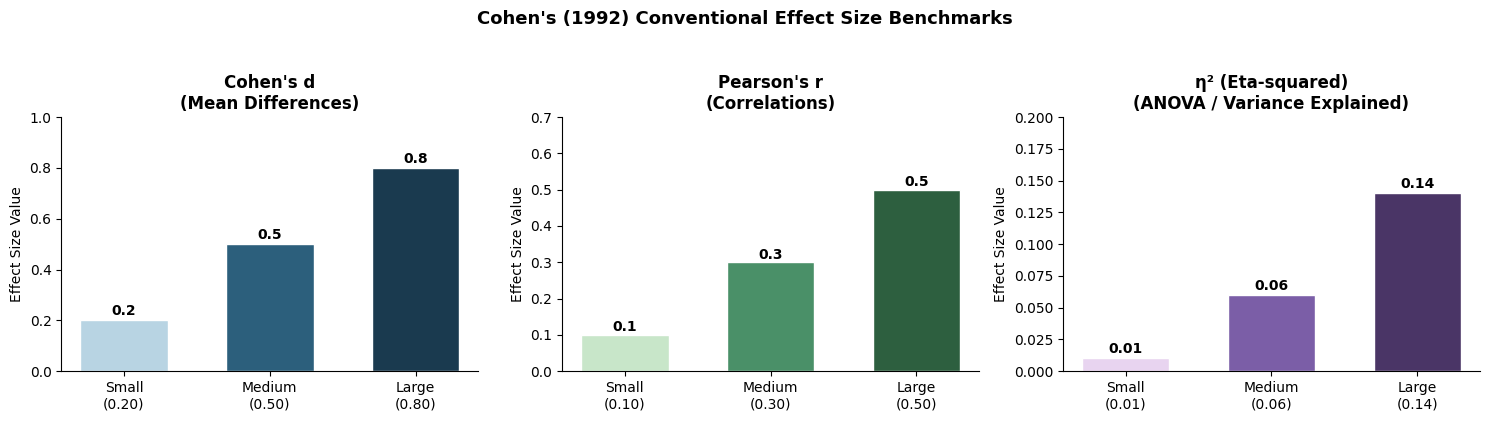

Remember: These are conventions, not absolute standards.
Always interpret effect sizes in the context of your research domain.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cohen's d
ax = axes[0]
categories = ["Small\n(0.20)", "Medium\n(0.50)", "Large\n(0.80)"]
values = [0.20, 0.50, 0.80]
bars = ax.bar(categories, values, color=["#b8d4e3", "#2c5f7c", "#1a3a4f"],
              edgecolor="white", width=0.6)
ax.set_ylabel("Effect Size Value")
ax.set_title("Cohen's d\n(Mean Differences)", fontweight="bold")
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val}", ha="center", fontweight="bold")

# Pearson's r
ax = axes[1]
values = [0.10, 0.30, 0.50]
bars = ax.bar(categories[:3], values, color=["#c8e6c9", "#4a9068", "#2d5f3f"],
              edgecolor="white", width=0.6)
labels = ["Small\n(0.10)", "Medium\n(0.30)", "Large\n(0.50)"]
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel("Effect Size Value")
ax.set_title("Pearson's r\n(Correlations)", fontweight="bold")
ax.set_ylim(0, 0.7)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val}", ha="center", fontweight="bold")

# Eta-squared
ax = axes[2]
values = [0.01, 0.06, 0.14]
bars = ax.bar(categories[:3], values, color=["#e8d4f0", "#7b5ea7", "#4a3566"],
              edgecolor="white", width=0.6)
labels = ["Small\n(0.01)", "Medium\n(0.06)", "Large\n(0.14)"]
ax.set_xticks(range(3))
ax.set_xticklabels(labels)
ax.set_ylabel("Effect Size Value")
ax.set_title("η² (Eta-squared)\n(ANOVA / Variance Explained)", fontweight="bold")
ax.set_ylim(0, 0.20)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f"{val}", ha="center", fontweight="bold")

plt.suptitle("Cohen's (1992) Conventional Effect Size Benchmarks",
             fontsize=13, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

print("Remember: These are conventions, not absolute standards.")
print("Always interpret effect sizes in the context of your research domain.")


---

## Your Turn

Now try adapting these tools for your own data:

1. **Replace the simulated data** with your own pilot data or numbers from studies you're reading
2. **Run the assumption dashboard** on your continuous variables before choosing between parametric and nonparametric tests
3. **Calculate Cronbach\'s alpha** if you're developing or using a survey instrument
4. **Save any charts** you generate (right-click → Save Image As) for your block deliverables or methodology chapter
5. **Use the APA-formatted output** as a template for reporting your own results

```{tip}
If you get an error about a missing library, add a new cell at the very top of the notebook and run:
`!pip install scipy matplotlib numpy`
```
